# Notebook 3 — Daily heat hazard (T2M) and population exposure (for CLIMADA)

This notebook takes the gridded outputs from Notebook 2 and turns them into **CLIMADA hazard and exposure objects**, consistently aligned on the UrbClim T2M grid for [city of choice]. It also attaches social vulnerability information (from my vulnerability_layer.py) and scales exposure over time for different population scenarios.

Concretely, it:

- **Loads common inputs from Notebook 2**
  - Reuses the **reference grid** (`template_ref.tif`), **city mask** (`city_mask.tif/npz`), **FUA geometry** (`rome_fua.gpkg`), and **baseline population by age group** (`age_on_ref_rome.npz`, `pop_on_ref_rome.npz`).
  - Reads the **T2M hazard manifest** to get the daily mean temperature files for **2030, 2040, 2050** (already masked to the FUA and in °C).
  - Loads the **vulnerability layer** on the same grid (Social Vulnerability Index, SVI, and components) if available.

- **Builds a daily T2M hazard for CLIMADA**
  - Computes **one centroid per UrbClim grid cell**:
    - Converts the 2D grid in EPSG:3035 to **lat/lon (EPSG:4326)** for CLIMADA’s `Centroids`.
  - Assembles a **daily intensity matrix**:
    - For each day in 2030, 2040, and 2050, reads the 2D T2M field, applies the city mask, fills outside-FUA cells with 0, and flattens to a row.
    - Stacks all days into a large sparse matrix `I_daily` (rows = days, columns = grid cells).
  - Defines the **fraction/footprint matrix**:
    - Repeats the city mask as 0/1 fractions for each event, so CLIMADA knows which centroids are active.
  - Creates a CLIMADA `Hazard` object:
    - `haz_type = "T2M"`, units = `"degC (daily mean)"`.
    - One **event per day**, with event IDs `YYYYMMDD`, event dates, and origin metadata.
    - Sets **event frequencies to 1/day-of-year** so that the sum of frequencies in each year is 1, ensuring consistent “per-year” expectations (conversely to before, when we were using WBGT, where the hazard was yearly and so we were taking a frequency of 1 per event).

- **Constructs population exposure on the same centroids**
  - Aggregates **baseline WorldPop 2030 population** to the hazard centroids:
    - Uses three age groups: **`<15`**, **`15–64`**, **`65+`**.
    - Keeps only centroids where population > 0 and inside the city mask.
  - Builds a CLIMADA `Exposures` object:
    - One point per active centroid and age group, with attributes:
      - `value` = number of people,
      - `age_group` and a simple `impf_T2M` ID per age group,
      - `geometry` in EPSG:4326.
    - Provides overall totals and breakdown by age group and a diagnostic map of **people per T2M cell**.

- **Attaches social vulnerability and defines quintiles**
  - If the vulnerability layer is available:
    - Interpolates the **SVI** (and its components) from the ref grid onto the exposure points.
    - Adds a continuous `vulnerability` value to each exposure point.
  - Builds two types of **SVI quintiles**:
    - `vuln_quintile` (row-based): splits the distribution of SVI values into five equal-sized **sets of points** (20% of points per quintile).
    - `vuln_quintile_pop` (population-weighted): sorts points by SVI and splits them into five groups each holding **20% of the total population**.
  - Key insights (Rome example):
    - The **median SVI is above 0.5**, meaning more than half of points are in relatively high vulnerability areas.
    - With row-based quintiles, only **≈7% of the population** lies in the lowest-vulnerability quintile, while **>50%** are in the highest two quintiles — population is **disproportionately concentrated in more vulnerable areas**.
    - Population-weighted quintiles intentionally hold **20% of residents per group**, useful for later analyses focused on “most vulnerable 20%” vs. others.

- **Saves CLIMADA-ready hazard and exposure products**
  - Writes:
    - `hazard_T2M_daily_rome.h5` (daily T2M hazard),
    - `exposure_people_rome.h5` (baseline exposure on T2M centroids),
    - CSVs with:
      - Event metadata (`hazard_T2M_daily_events_rome.csv`),
      - **Daily** city-mean T2M and frequencies (`hazard_events_T2M_daily_rome.csv`),
      - **Yearly** summaries (`hazard_events_T2M_yearly_rome.csv`).

- **Generates future exposure with vulnerability for multiple scenarios**
  - Reads `exposure_manifest.json` from Notebook 2, which maps each **scenario × year** (SSP1, SSP2, SSP3, SSP4, SSP5, SSP2DM, SSP2ZM; 2030, 2040, 2050) to:
    - Future age-group grids (`age_npz`),
    - Future total population grids (`pop_npz`).
  - For each scenario and year:
    - Starts from the **baseline exposure with vulnerability**.
    - Computes an **age-specific scaling factor** per cell (future age grid / baseline age grid).
    - Scales the exposure `value` for each point in that age group accordingly, preserving spatial patterns and the attached vulnerability, but updating counts.
    - Checks that the sum of exposure values matches the corresponding future population grid.
    - Saves to `exposure_with_vulnerability_rome_{SCEN}_{YEAR}.h5`.
  - The result is a **consistent family of exposure datasets** by scenario and year, all:
    - On the same centroids as the hazard,
    - Age-disaggregated,
    - Enriched with SVI and vulnerability quintiles.

In summary, Notebook 3 **bridges gridded climate, population, and vulnerability data into CLIMADA hazard and exposure objects**, and prepares a scenario- and year-resolved exposure ensemble that downstream risk and adaptation analyses can use directly.

In [22]:
import os
os.environ["CITY"] = "genova"   # pick the city here

In [23]:
# generic bootstrap 
from pathlib import Path
import os, sys

def _find_root():
    start = Path.cwd()
    for cand in [start, *start.parents]:
        if (cand/"cityheat").is_dir() and (cand/"configs").is_dir():
            return cand
    raise RuntimeError("Repo root not found.")
ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from cityheat.nbsetup import bootstrap
from cityheat.paths import make_P, ensure_out

# choose city here
SLUG = globals().get("SLUG", os.environ.get("CITY", "rome")).lower()

C    = bootstrap(SLUG)      # reads configs/<slug>.yml and syncs that city only if wanted
CFG  = C["CFG"]; CITY = C["CITY"]
BASE = C["BASE"]; OUT = C["OUT"]; INT = C["INT"]

P    = make_P(BASE)         # read-only path helper
OUTP = ensure_out(OUT)      # write-safe path helper
print(f"→ City: {CITY}  |  BASE={BASE}  OUT={OUT}  INT={INT}")

→ City: genova  |  BASE=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/genova  OUT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova  INT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim


In [24]:
cfg  = C.get("cfg")     # dict loaded from YAML

In [25]:
age_npz = INT / f"age_on_ref_{SLUG}.npz"

pop_npz = INT / f"pop_on_ref_{SLUG}.npz"

needed_nb2 = [
    INT / "template_ref.tif",
    INT / "city_mask.tif",
    age_npz,
    pop_npz,
    OUT / f"{SLUG}_fua.gpkg",
    INT / "hazard_manifest.json",
]

missing = [p for p in needed_nb2 if not p.exists()]
if missing:
    raise FileNotFoundError("Re-run Notebook 2. Missing:\n" + "\n".join(map(str, missing)))

**Imports**

In [26]:
import json
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

import rasterio as rio
from rasterio.mask import mask as rio_mask
from rasterio.warp import reproject
from rasterio.enums import Resampling
from rasterio.transform import array_bounds

from climada.hazard import Hazard, Centroids
from scipy import sparse

plt.rcParams.update({"figure.dpi": 130})

In [27]:
from pathlib import Path
import json, numpy as np, rasterio as rio
import geopandas as gpd

# meta/georef, city mask, age/pop rasters on WBGT grid, FUA, hazard manifest
tmpl_path = INT / "template_ref.tif"
mask_tif  = INT / "city_mask.tif"
mask_npz  = INT / "city_mask.npz"
fua_gp    = OUT / f"{SLUG}_fua.gpkg"
manifest  = INT / "hazard_manifest.json"
exp_meta  = INT / "exposure_meta.json"

age_npz_candidates = [INT / f"age_on_ref_{SLUG}.npz", INT / "age_on_ref.npz"]
pop_npz_candidates = [INT / f"pop_on_ref_{SLUG}.npz", INT / "pop_on_ref.npz"]

def first_existing(paths):
    for p in paths:
        if p.exists():
            return p
    return paths[0]  

age_npz = first_existing(age_npz_candidates)
pop_npz = first_existing(pop_npz_candidates)

# Template meta
with rio.open(tmpl_path) as src:
    ref_meta = src.meta.copy()
    HGT, WDT = ref_meta["height"], ref_meta["width"]

# CITY_MASK
if mask_tif.exists():
    with rio.open(mask_tif) as src:
        CITY_MASK = src.read(1).astype(bool)
elif mask_npz.exists():
    CITY_MASK = np.load(mask_npz)["city_mask"].astype(bool)
else:
    raise FileNotFoundError("city_mask.tif/npz not found. Re-run Notebook 2.")

assert CITY_MASK.shape == (HGT, WDT)
ref_data = np.where(CITY_MASK, 0.0, np.nan)

# Age/pop rasters on T2M grid
agez = np.load(age_npz)
age_on_ref = {"<15": agez["lt15"], "15-64": agez["a15_64"], "65+": agez["g65"]}
pop_on_ref = np.load(pop_npz)["pop"]

# metadata for exposures
try:
    year = int(json.load(open(exp_meta))["worldpop_year"])
except Exception:
    year = 2030

# FUA geometry
if not fua_gp.exists():
    raise FileNotFoundError(f"{fua_gp.name} not found. Re-run Notebook 2 to save FUA.")
fua = gpd.read_file(fua_gp, layer="fua")
if fua.empty:
    raise ValueError("FUA is empty.")

# T2M hazard manifest from NB2 
man_path = INT / "hazard_manifest.json"
man = json.load(open(man_path))
assert man.get("hazard_type") == "t2m_daily_mean", f"Unexpected hazard_type: {man.get('hazard_type')}"

years = sorted(map(int, man["files"].keys()))
t2m_paths = {int(y): Path(p) for y, p in man["files"].items()}
print("T2M years:", years)

T2M years: [2030, 2040, 2050]


In [28]:
# loading vulnerability layer (SVI on the same reference grid)
from cityheat.vulnerability_layer import (
    load_vulnerability,
    add_vulnerability_to_exposure_gdf,
)

In [29]:
try:
    vuln = load_vulnerability(INT, SLUG)
    svi_grid = vuln["svi"]          # 2D array on ref grid
    HAS_VULN = True
    print(f"Loaded vulnerability layer. "
          f"SVI mean={np.nanmean(svi_grid):.3f}, std={np.nanstd(svi_grid):.3f}")
    assert svi_grid.shape == (HGT, WDT), "SVI grid shape != ref grid shape"
except FileNotFoundError:
    svi_grid = None
    HAS_VULN = False
    print("No vulnerability layer found in INT – continuing without SVI.")

Loaded vulnerability layer. SVI mean=0.554, std=0.230


## Hazard

> **Hazard: daily mean temperature (temperature and not days anymore + daily and not annual hazard)**
> - Building CLIMADA centroids
> - Assembling daily intensity matrix
> - Defining fraction/footprint
> - CLIMADA hazard building

In [30]:
# DAILY T2M hazard (one event per day)
import xarray as xr
from scipy import sparse
from pyproj import Transformer
from climada.hazard import Hazard, Centroids

# Centroids (grid native is EPSG:3035 so we need to convert to EPSG:4326 for CLIMADA) 
# here we take the UrbClim grid, we compute each cell center, then we convert the coordinates to WBGS83 because CLIMADA's centroids expect lat/lon
# we sanity check to see that one centroid per grid cell
rows, cols = np.indices((HGT, WDT))
xs_m, ys_m = rio.transform.xy(ref_meta["transform"], rows, cols, offset="center")
x_flat = np.asarray(xs_m, float).ravel()   # meters (EPSG:3035)
y_flat = np.asarray(ys_m, float).ravel()
to_wgs84 = Transformer.from_crs(ref_meta["crs"], "EPSG:4326", always_xy=True)
lon, lat = to_wgs84.transform(x_flat, y_flat)
Ctd = Centroids(lat=np.asarray(lat, float), lon=np.asarray(lon, float))

assert (getattr(ref_meta["crs"], "to_epsg", lambda: None)() == 3035), "ref grid not EPSG:3035?"
assert len(Ctd.lat) == HGT*WDT and len(Ctd.lon) == HGT*WDT, "centroids length mismatch"

# building daily intensity rows 
# we assemble the daily intensity matrix 
# for each target year file (°C + masked FUA) we loop over every day
# we extract that day's 2D °C field, keep values inside city mask and set outside to na, we replace na by 0
# we flatten 2D field into one long row: stack all days => big n_days * n_cells matrix in CRS sparse form I_daily
I_rows, dates, years_of = [], [], []
for y in years:
    da = xr.open_dataset(t2m_paths[y])["T2M"]  # (time,y,x) in °C, already masked to FUA in NB2
    for t in da.time.values:
        arr = da.sel(time=t).values
        arr = np.where(CITY_MASK, arr, np.nan)
        I_rows.append(np.nan_to_num(arr, nan=0.0).ravel().astype("float32"))
        d = np.datetime64(t, "D")
        dates.append(d)
        years_of.append(int(str(d)[:4]))

# each row = one day's temperature map
I_daily = sparse.csr_matrix(np.vstack(I_rows))  # shape = (n_days_total, HGT*WDT)

# defining fraction/footprint for each day 
# F_daily: same shape as I_daily but just 0/1 city mask repeated for each day
# in CLIMADA, fraction: what fraction of each cell affected/valid. Here it's 1 inside FUA cell, 0 outside
mask_vec = CITY_MASK.ravel().astype(float)
F_daily = sparse.csr_matrix(np.vstack([mask_vec] * I_daily.shape[0]))

assert I_daily.shape[1] == HGT*WDT, "events x cells shape off"
assert F_daily.shape == I_daily.shape, "fraction footprint mismatch"

# Hazard object (daily events) 
H = Hazard("T2M")
H.haz_type   = "T2M"
H.units      = "degC (daily mean)"
H.orig       = np.array([f"{CITY}_UrbClim_T2Mmean_daily"] * I_daily.shape[0], dtype=object)
H.event_id   = np.array([int(pd.Timestamp(d).strftime("%Y%m%d")) for d in dates], dtype=int)
H.event_name = np.array([f"T2M_{str(d)}" for d in dates], dtype=object)
H.date       = np.array(dates, dtype="datetime64[ns]")
H.frequency  = np.ones(I_daily.shape[0], dtype=float)
H.centroids  = Ctd
H.intensity  = I_daily
H.fraction   = F_daily

H.check()
print(H)

For WBGT, frequency is 1 because it's one year, but here frequency should be 1/year : each day. Frequency is the weight each event has when we convert a list of events into an average per year. If each event is a day, then each day should count as 1/365 (or 1/366 in leap years) so that all days in a year add up to “one year”. If we leave frequency at 1, any “expected annual” metric will be 365× too big.

In [31]:
import numpy as np
import pandas as pd

# years for each event (one row per day)
years = pd.to_datetime(H.date).year.to_numpy()

def days_in_year(y): 
    return 366 if (y % 4 == 0 and (y % 100 != 0 or y % 400 == 0)) else 365

H.frequency = np.array([1.0 / days_in_year(y) for y in years], dtype=float)
H.frequency_unit = "1/year"

**plots**

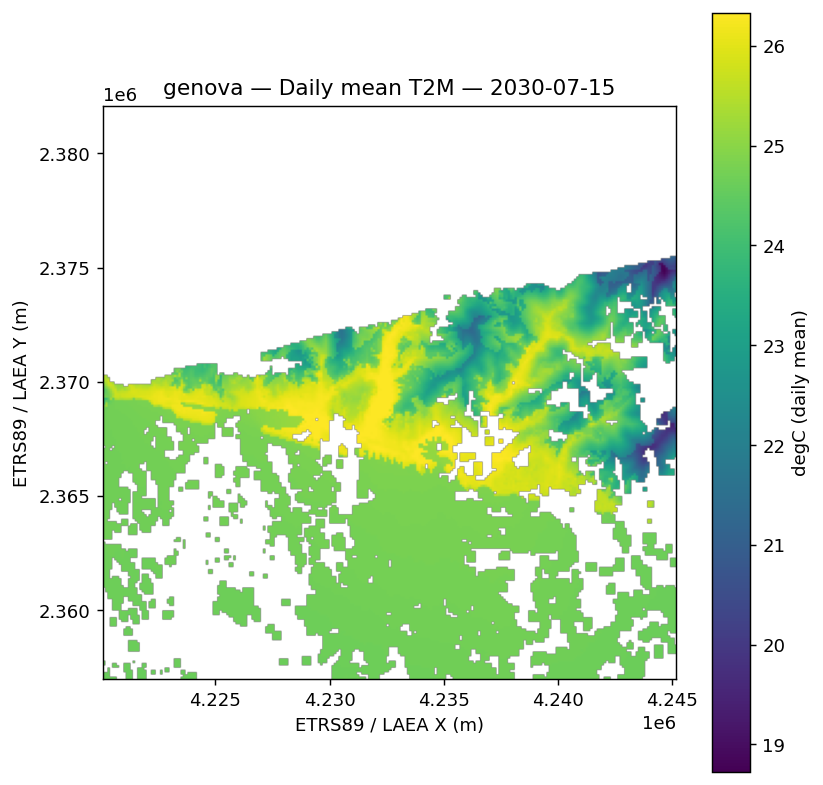

In [32]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from rasterio.transform import array_bounds

# Extent (3035, same as rasters)
T = ref_meta["transform"]
left, bottom, right, top = array_bounds(HGT, WDT, T)
extent = (left, right, bottom, top)

def plot_t2m_day(H, date_str):
    d = np.datetime64(date_str, 'D')
    idx = np.where(H.date.astype('datetime64[D]') == d)[0]
    if idx.size == 0:
        raise KeyError(f"No event for {date_str}")
    r = int(idx[0])

    arr = H.intensity.getrow(r).toarray().reshape(HGT, WDT)
    m = np.ma.masked_where(~CITY_MASK, arr)
    vmax = np.nanpercentile(m.compressed(), 99)

    plt.figure(figsize=(6.5, 6.2))
    im = plt.imshow(
        m,
        origin="lower",         
        extent=extent,          
        vmin=m.min(),
        vmax=vmax,
    )
    cb = plt.colorbar(im); cb.set_label("degC (daily mean)")
    plt.title(f"{CITY} — Daily mean T2M — {np.datetime_as_string(d, unit='D')}")
    plt.xlabel("ETRS89 / LAEA X (m)")
    plt.ylabel("ETRS89 / LAEA Y (m)")
    plt.gca().set_aspect('equal', 'box')
    plt.tight_layout(); plt.show()

plot_t2m_day(H, "2030-07-15")

In [33]:
# Per-year frequency sums should be 1
import numpy as np, pandas as pd
yr = pd.to_datetime(H.date).year
chk = pd.Series(H.frequency).groupby(yr).sum()
print(chk)  # expecting 1.0 for 2030, 2040, 2050

# Daily summary: mean of means per year should match yearly_summary
daily = pd.read_csv(INT / f"hazard_events_T2M_daily_{SLUG}.csv", parse_dates=["date"])
print(daily.groupby(daily["date"].dt.year)["frequency"].sum())  # again 1 each year

2030    1.0
2040    1.0
2050    1.0
dtype: float64
date
2030    1.0
2040    1.0
2050    1.0
Name: frequency, dtype: float64


## Exposure on same centroids 

**Aggregating Worldpop to grid**

description: None
ref_year: 2030
value_unit: people
crs: EPSG:4326
data: (79752 entries)
          value age_group  impf_T2M                  geometry
0      0.080336       <15         1  POINT (8.73299 44.54156)
1      0.106683       <15         1  POINT (8.73425 44.54158)
2      0.011052       <15         1   POINT (8.7355 44.54159)
3      0.005164       <15         1  POINT (8.73676 44.54161)
79748  4.692616       65+         3  POINT (9.04969 44.37991)
79749  0.314396       65+         3   POINT (9.0472 44.37898)
79750  0.508377       65+         3  POINT (9.04845 44.37899)
79751  0.023688       65+         3    POINT (9.04971 44.379)
Total people in exposure (T2M grid): 576549.766326806
Breakdown by age group (T2M grid):
age_group
15-64    334769.043136
65+      188747.155729
<15       53033.567462
Name: value, dtype: float64


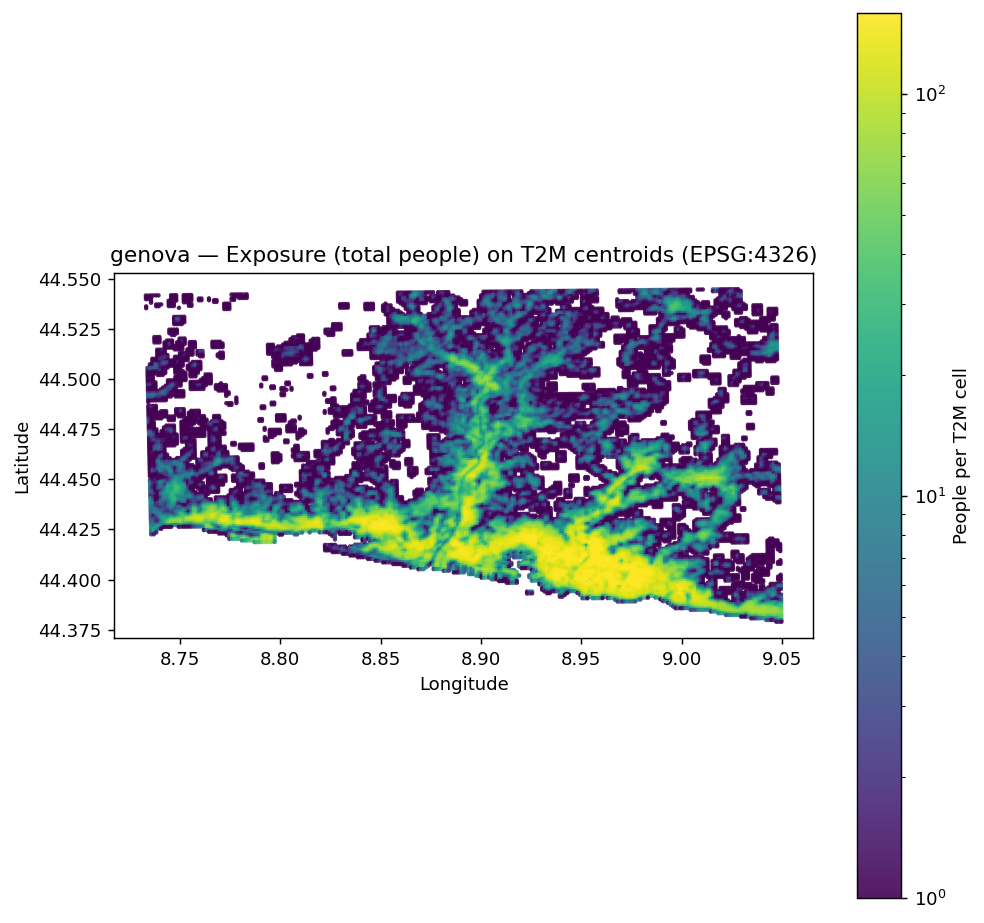

Exposure total (check): 576,550 people


In [34]:
# Exposure on same centroids (T2M grid) 

# valid pixels (same mask used for hazard on the T2M grid)
haz_valid = CITY_MASK.ravel()

# IF ids for T2M 
impf_id_T2M = {"<15": 1, "15-64": 2, "65+": 3}

# stack age bands at T2M centroids where pop>0
frames = []
for grp, raster in age_on_ref.items():
    pop_flat = np.nan_to_num(raster, nan=0.0).ravel().astype(float)
    valid = haz_valid & (pop_flat > 0)
    if valid.any():
        frames.append(
            gpd.GeoDataFrame(
                {
                    "value":     pop_flat[valid],
                    "longitude": lon[valid],    # lon from the T2M centroids built
                    "latitude":  lat[valid],    # lat from the T2M centroids built
                    "age_group": np.full(valid.sum(), grp, dtype=object),
                    "impf_T2M":  np.full(valid.sum(), impf_id_T2M[grp], dtype=int),
                },
                geometry=gpd.points_from_xy(lon[valid], lat[valid]),
                crs="EPSG:4326",
            )
        )

gdf = pd.concat(frames, ignore_index=True) if frames else gpd.GeoDataFrame(
    columns=["value","longitude","latitude","age_group","impf_T2M","geometry"], crs="EPSG:4326"
)

# CLIMADA Exposures
from climada.entity.exposures import Exposures
exp = Exposures()
exp.set_gdf(gdf)
exp.value_unit = "people"
exp.ref_year   = year
exp.tag        = f"{CITY} FUA — WorldPop age groups ({year}) on T2M (UrbClim) grid"
exp.check()

print(exp)
if not exp.gdf.empty:
    print("Total people in exposure (T2M grid):", float(exp.gdf["value"].sum()))
    print("Breakdown by age group (T2M grid):")
    print(exp.gdf.groupby("age_group")["value"].sum().astype(float))

# map (people per T2M cell)
from matplotlib.colors import LogNorm
vals_all  = np.nan_to_num(pop_on_ref, nan=0.0)
valid_all = CITY_MASK
vmax = np.nanpercentile(vals_all[valid_all], 99) if valid_all.any() else 1.0
norm = LogNorm(vmin=1, vmax=max(1.0, vmax))

plt.figure(figsize=(7.8, 7.2))
sc = plt.scatter(lon[valid_all.ravel()], lat[valid_all.ravel()],
                 c=vals_all.ravel()[valid_all.ravel()], s=6, linewidths=0, alpha=0.9, norm=norm)
cb = plt.colorbar(sc); cb.set_label("People per T2M cell")
plt.title(f"{CITY} — Exposure (total people) on T2M centroids (EPSG:4326)")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.gca().set_aspect('equal', 'box')
plt.tight_layout(); plt.show()

print(f"Exposure total (check): {vals_all[valid_all].sum():,.0f} people")

In [35]:
if HAS_VULN:
    # adding vulnerability to exposure
    add_vulnerability_to_exposure_gdf(exp.gdf, svi_grid, ref_meta)
    print("Added vulnerability column to exposure.")

    # clean SVI
    svi_series = exp.gdf["vulnerability"].replace([np.inf, -np.inf], np.nan)
    median_svi = svi_series.median()
    svi_filled = svi_series.fillna(median_svi)

    # row-based SVI quintiles
    exp.gdf["vuln_quintile"] = pd.qcut(
        svi_filled,
        5,
        labels=["Q1-Low", "Q2", "Q3", "Q4", "Q5-High"]
    )

    print(exp.gdf[["value", "vulnerability", "vuln_quintile"]].describe(include="all"))

    # population-weighted SVI quintiles
    # sorting by SVI, compute cumulative population share, then cut into 5 x 20%
    tmp = exp.gdf.copy()
    tmp["svi_filled"] = svi_filled

    tmp = tmp.sort_values("svi_filled")
    tmp["cum_pop"] = tmp["value"].cumsum()
    total_pop = tmp["value"].sum()
    tmp["cum_pop_frac"] = tmp["cum_pop"] / total_pop

    labels = ["Q1-Low", "Q2", "Q3", "Q4", "Q5-High"]
    tmp["vuln_quintile_pop"] = pd.cut(
        tmp["cum_pop_frac"],
        bins=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0],
        labels=labels,
        include_lowest=True
    )

    # putting the pop-weighted quintile back on the original GeoDataFrame
    exp.gdf["vuln_quintile_pop"] = tmp.sort_index()["vuln_quintile_pop"]

else:
    print("No SVI attached to exposure (HAS_VULN=False).")

# Diagnostics for row-based quintile
print(exp.gdf[["value", "vulnerability"]].describe())

print("\nRow-based SVI quintile counts:")
print(exp.gdf["vuln_quintile"].value_counts())

pop_by_q = exp.gdf.groupby("vuln_quintile", observed=False)["value"].sum()
print("\nPopulation by row-based quintile:")
print(pop_by_q.round(0))
print("\nShare of total (row-based):")
print((pop_by_q / pop_by_q.sum() * 100).round(1))

# Diagnostics for pop-weighted quintile 
pop_by_q_pop = exp.gdf.groupby("vuln_quintile_pop", observed=False)["value"].sum()
print("\nPopulation by pop-weighted SVI quintile:")
print(pop_by_q_pop.round(0))
print("\nShare of total (pop-weighted):")
print((pop_by_q_pop / pop_by_q_pop.sum() * 100).round(1))

Added vulnerability column to exposure.
               value  vulnerability vuln_quintile
count   7.975200e+04   77400.000000         79752
unique           NaN            NaN             5
top              NaN            NaN        Q1-Low
freq             NaN            NaN         16017
mean    7.229283e+00       0.553999           NaN
std     1.566430e+01       0.229687           NaN
min     2.241892e-07       0.000000           NaN
25%     1.577323e-01       0.401977           NaN
50%     9.354907e-01       0.568321           NaN
75%     5.243225e+00       0.726684           NaN
max     1.041742e+02       1.000000           NaN
              value  vulnerability
count  7.975200e+04   77400.000000
mean   7.229283e+00       0.553999
std    1.566430e+01       0.229687
min    2.241892e-07       0.000000
25%    1.577323e-01       0.401977
50%    9.354907e-01       0.568321
75%    5.243225e+00       0.726684
max    1.041742e+02       1.000000

Row-based SVI quintile counts:
vuln_quintile

In [36]:
from pandas.api.types import CategoricalDtype

# ensuring quintile columns are non-categorical for HDF5 storage
for col in ["vuln_quintile", "vuln_quintile_pop"]:
    if HAS_VULN and col in exp.gdf.columns:
        if isinstance(exp.gdf[col].dtype, CategoricalDtype):
            exp.gdf[col] = exp.gdf[col].astype(str)
            print(f"Converted {col} from categorical → string for HDF5 storage.")

Converted vuln_quintile from categorical → string for HDF5 storage.
Converted vuln_quintile_pop from categorical → string for HDF5 storage.


**Interpretation:**
- two different quintile variables on exposure points: vuln_quintile (row-based SVI quintiles ie taking SVI at each exposure point, after filling missing values with median, cutting distribution of SVI values into 5 equal-sized groups by number of rows (points) => 20% of points in each of quintile.
- vuln_quintile_pop: pop-weighted SVI quintiles => sorting exposure points by SVI, computing cumulative pop with cum_pop and its fraction of total (cum_pop_frac): fixed breaks cumulative pop => so each quintile holds 20% of pop by construction, but number of points per quintile can differ. 

- median SVI is > 0.5 ⇒ more than half the points have above-mid vulnerability
- row-based quintiles: equal numbers of exposure points in each SVI quintile (but not of people). DO INTERPRETATION FOR GENOVA. 
- Then, quintiles with 20% of total pop in each quintile. Interesting to look at heat exposure among the most vulnerable 20% of residents for example, or for later doing vulnerability based policy. Equal ppl per group. 

**Save for future notebooks**

In [37]:
# closing any previously-open HDF5 handles (always this same pb when files not closed)
import tables
tables.file._open_files.close_all()

# saving daily hazard + exposures
haz_path = INT / f"hazard_T2M_daily_{SLUG}.h5"
exp_path = INT / f"exposure_people_{SLUG}.h5"

H.write_hdf5(haz_path)
exp.write_hdf5(exp_path)
print("Saved daily hazard →", haz_path, "| days:", H.intensity.shape[0])

# row-date map (HDF5 drops date/event_name)
dates_df = pd.DataFrame({
    "row": np.arange(H.intensity.shape[0], dtype=int),
    "event_id": np.asarray(H.event_id, dtype=int),
    "date": pd.to_datetime(H.date).astype(str),
})
dates_csv = INT / f"hazard_T2M_daily_events_{SLUG}.csv"
dates_df.to_csv(dates_csv, index=False)
print("Saved events map →", dates_csv)

# daily summary (one row per day)
mean_by_event = np.asarray(H.intensity.mean(axis=1)).ravel()  # citywide mean °C per day
daily_summary = pd.DataFrame({
    "row": np.arange(H.intensity.shape[0], dtype=int),
    "event_id": np.asarray(H.event_id, dtype=int),
    "date": pd.to_datetime(H.date),
    "frequency": np.asarray(H.frequency, dtype=float),
    "mean_intensity_degC": mean_by_event,
})
daily_csv = INT / f"hazard_events_T2M_daily_{SLUG}.csv"
daily_summary.to_csv(daily_csv, index=False)
print("Saved daily summary →", daily_csv)

# if we needed also a yearly summary (aggregate daily to year)
yearly_summary = (
    daily_summary
    .assign(year=lambda d: d["date"].dt.year.astype(int))
    .groupby("year", as_index=False)
    .agg(
        n_days=("row", "count"),
        citymean_degC=("mean_intensity_degC", "mean")
    )
)
yearly_csv = INT / f"hazard_events_T2M_yearly_{SLUG}.csv"
yearly_summary.to_csv(yearly_csv, index=False)
print("Saved yearly summary →", yearly_csv)

2025-12-09 18:30:10,958 - climada.hazard.io - WARNING - write_hdf5: the class member date is skipped, due to its type, ndarray, for which writing to hdf5 is not implemented. Reading this H5 file will probably lead to date being set to its default value.
Saved daily hazard → /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim/hazard_T2M_daily_genova.h5 | days: 1096
Saved events map → /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim/hazard_T2M_daily_events_genova.csv
Saved daily summary → /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim/hazard_events_T2M_daily_genova.csv
Saved yearly summary → /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim/hazard_events_T2M_yearly_genova.csv


In [38]:
# saving daily hazard + exposures
haz_path = INT / f"hazard_T2M_daily_{SLUG}.h5"
exp_path = INT / f"exposure_people_{SLUG}.h5"
H.write_hdf5(haz_path)
exp.write_hdf5(exp_path)
print("Saved daily hazard →", haz_path, "| days:", H.intensity.shape[0])

# also copy to OUT so other notebooks can find it easily
import shutil
haz_path_out = OUT / f"hazard_T2M_daily_{SLUG}.h5"
exp_path_out = OUT / f"exposure_people_{SLUG}.h5"
haz_path_out.parent.mkdir(parents=True, exist_ok=True)
exp_path_out.parent.mkdir(parents=True, exist_ok=True)
shutil.copy2(haz_path, haz_path_out)
shutil.copy2(exp_path, exp_path_out)
print("Copied to OUT →", haz_path_out)
print("Copied to OUT →", exp_path_out)

2025-12-09 18:30:11,446 - climada.hazard.io - WARNING - write_hdf5: the class member date is skipped, due to its type, ndarray, for which writing to hdf5 is not implemented. Reading this H5 file will probably lead to date being set to its default value.
Saved daily hazard → /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim/hazard_T2M_daily_genova.h5 | days: 1096
Copied to OUT → /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/hazard_T2M_daily_genova.h5
Copied to OUT → /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/exposure_people_genova.h5


In [39]:
import numpy as np
import pandas as pd
import rasterio as rio

# loading grid shape from template_ref.tif
tmpl_path = INT / "template_ref.tif"
with rio.open(tmpl_path) as src:
    HGT, WDT = src.height, src.width

n_days, n_cells = H.intensity.shape
assert n_cells == HGT * WDT, f"Cells {n_cells} != HGT*WDT = {HGT*WDT}"

# Year per event
dates = pd.to_datetime(pd.Series(H.date))
years = dates.dt.year.to_numpy().astype(int)
uniq_years = np.unique(years)

# For each year, computing mean daily T2M per cell and reshape to 2D
DATA = np.empty((len(uniq_years), HGT, WDT), dtype="float32")
for k, yr in enumerate(uniq_years):
    mask = (years == yr)
    # mean over days in that year => one value per cell
    arr_1d = np.asarray(H.intensity[mask].mean(axis=0), dtype="float32")
    DATA[k, :, :] = arr_1d.reshape(HGT, WDT)

# saving as npz 
t2m_npz_path = INT / f"t2m_hazard_2030_2100_{SLUG}.npz"
np.savez_compressed(t2m_npz_path, years=uniq_years, data=DATA)
print("Saved yearly T2M hazard grid →", t2m_npz_path)

Saved yearly T2M hazard grid → /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim/t2m_hazard_2030_2100_genova.npz


In [41]:
# saving baseline exposure with vulnerability for scaling 

from climada.entity.exposures import Exposures
import shutil

base_exp_path = INT / f"exposure_with_vulnerability_{SLUG}.h5"
exp.write_hdf5(base_exp_path)
print("Saved baseline exposure-with-vulnerability →", base_exp_path)

# also copying to OUT
base_exp_out = OUT / base_exp_path.name
shutil.copy2(base_exp_path, base_exp_out)
print("Copied to OUT →", base_exp_out)

Saved baseline exposure-with-vulnerability → /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim/exposure_with_vulnerability_genova.h5
Copied to OUT → /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/exposure_with_vulnerability_genova.h5


In [42]:
import json
import numpy as np
from climada.entity import Exposures

# loading baseline exposure (2030) with vulnerability
base_exp_path = INT / f"exposure_with_vulnerability_{SLUG}.h5"
print("Reading baseline exposure from:", base_exp_path)
exp_base = Exposures.from_hdf5(base_exp_path)

# loading baseline total population, age bands, and city mask from NB2/NB3
pop_base = np.load(INT / f"pop_on_ref_{SLUG}.npz")["pop"].astype("float32")   # (H, W)
agez = np.load(INT / f"age_on_ref_{SLUG}.npz")
age_on_ref = {
    "<15":   agez["lt15"],
    "15-64": agez["a15_64"],
    "65+":   agez["g65"],
}

CITY_MASK = np.load(INT / "city_mask.npz")["city_mask"].astype(bool)          # (H, W)
HGT, WDT = CITY_MASK.shape
haz_valid = CITY_MASK.ravel()

# Sanity checks
assert pop_base.shape == (HGT, WDT)
for grp, arr in age_on_ref.items():
    assert arr.shape == (HGT, WDT), f"Age raster shape mismatch for {grp}"

# building mapping from exposure rows to underlying grid cells (once)

idx_by_group = {}
valid_by_group = {}

for grp, raster in age_on_ref.items():
    pop_flat_age = np.nan_to_num(raster, nan=0.0).ravel().astype(float)
    valid_age = haz_valid & (pop_flat_age > 0)
    valid_by_group[grp] = valid_age

    # Indices of cells for this age group
    cell_idx = np.where(valid_age)[0]

    # Rows in exposure corresponding to this age group
    rows_idx = np.where(exp_base.gdf["age_group"].values == grp)[0]

    print(f"Group {grp}: {valid_age.sum()} cells, {len(rows_idx)} exposure rows")
    assert len(cell_idx) == len(rows_idx), f"Mismatch for group {grp}"

    idx_by_group[grp] = (rows_idx, cell_idx)

print("Total exposure rows:", len(exp_base.gdf))

# loading exposure_manifest (scenario/year to NPZ paths)
with open(INT / "exposure_manifest.json") as f:
    expo_manifest = json.load(f)

# looping over scenarios and years, scale exposure values, and save

for scen_code, years_dict in expo_manifest["scenarios"].items():
    for year_str, rec in years_dict.items():
        year = int(year_str)

        # loadingfuture age grids for this scenario/year 
        ages_future_npz = np.load(rec["age_npz"])
        age_future = {
            "<15":   ages_future_npz["lt15"].astype("float32"),
            "15-64": ages_future_npz["a15_64"].astype("float32"),
            "65+":   ages_future_npz["g65"].astype("float32"),
        }

        # sanity check shapes
        for grp in ["<15", "15-64", "65+"]:
            assert age_future[grp].shape == age_on_ref[grp].shape

        # start from baseline exposure with vuln
        exp_y = exp_base.copy()

        # age-specific scaling 
        for grp in ["<15", "15-64", "65+"]:
            rows_idx, cell_idx = idx_by_group[grp]

            base_grid = age_on_ref[grp].astype("float32")
            fut_grid  = age_future[grp]

            # per-cell scale for this age group only
            scale_grid_grp = np.ones_like(base_grid, dtype="float32")
            mask_nonzero   = (base_grid > 0)

            scale_grid_grp[mask_nonzero] = (
                fut_grid[mask_nonzero] / base_grid[mask_nonzero]
            )

            scale_flat_grp = scale_grid_grp.ravel()
            scale_for_rows = scale_flat_grp[cell_idx]

            base_vals = exp_base.gdf.loc[rows_idx, "value"].values
            exp_y.gdf.loc[rows_idx, "value"] = base_vals * scale_for_rows

        # check vs total pop grid)
        pop_future = np.load(rec["pop_npz"])["pop"].astype("float32")
        tot_exp    = float(exp_y.gdf["value"].sum())
        tot_grid   = float(pop_future[CITY_MASK].sum())
        print(f"{scen_code} {year}: exposure={tot_exp:,.0f}  grid_pop={tot_grid:,.0f}")

        out_path = OUTP(f"exposure_with_vulnerability_{SLUG}_{scen_code}_{year}.h5")
        exp_y.write_hdf5(out_path)
        print("Saved", out_path)

Reading baseline exposure from: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim/exposure_with_vulnerability_genova.h5
Group <15: 26584 cells, 26584 exposure rows
Group 15-64: 26584 cells, 26584 exposure rows
Group 65+: 26584 cells, 26584 exposure rows
Total exposure rows: 79752
SSP1 2030: exposure=576,550  grid_pop=576,550
Saved /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/exposure_with_vulnerability_genova_SSP1_2030.h5
SSP1 2040: exposure=575,870  grid_pop=575,870
Saved /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/exposure_with_vulnerability_genova_SSP1_2040.h5
SSP1 2050: exposure=573,249  grid_pop=573,249
Saved /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/exposure_with_vulnerability_genova_SSP1_2050.h5
SSP2 2030: exposure=576,550  grid_pop=576,550
Saved /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/exposure_with_vulnerability_g